# RTO forecast

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as sm

from datetime import datetime, timedelta

## dataset 

### load forecast data

In [2]:
offset = 0

today = (pd.Timestamp.today() - pd.Timedelta(days=offset)).normalize()

today_str = (datetime.today() - timedelta(days=offset)).strftime("%m%d") 

load_forecast = pd.read_csv(f'data/load_frcstd_7_day/load_frcstd_7_day_{today_str}.csv', skiprows=[1])

load_forecast['forecast_load_mw'] = pd.to_numeric(load_forecast['forecast_load_mw'], errors='coerce')

In [3]:
load_forecast = load_forecast[['evaluated_at_datetime_ept', 'forecast_datetime_ending_ept', 'forecast_area', 'forecast_load_mw']].copy()

load_forecast["forecast_datetime_ending_ept"] = pd.to_datetime(load_forecast["forecast_datetime_ending_ept"])

load_forecast = load_forecast[load_forecast["forecast_datetime_ending_ept"] >= today]

load_forecast.head()

,evaluated_at_datetime_ept,forecast_datetime_ending_ept,forecast_area,forecast_load_mw
420388,2026-05-17 07:18:12.000,2026-05-19 05:00:00,PEPCO/MIDATL,2968.0
420389,2026-05-17 07:18:12.000,2026-05-19 04:00:00,PEPCO/MIDATL,2966.0
420390,2026-05-17 07:18:12.000,2026-05-19 03:00:00,PEPCO/MIDATL,3060.0
420391,2026-05-17 07:18:12.000,2026-05-19 02:00:00,PEPCO/MIDATL,3215.0
420392,2026-05-17 07:18:12.000,2026-05-19 01:00:00,PEPCO/MIDATL,3437.0


In [4]:
forecast_to_agg = {
    "AE/MIDATL": "AE",
    "AEP": "AEP",
    "AP": "AP",
    "ATSI": "ATSI",
    "BG&E/MIDATL": "BGE",
    "COMED": "COMED",
    "DAYTON": "DAYTON",
    "DEOK": "DEOK",
    "DOMINION": "DOM",
    "DP&L/MIDATL": "DPL",
    "DUQUESNE": "DUQ",
    "EKPC": "EKPC",
    "JCP&L/MIDATL": "JC",
    "METED/MIDATL": "METED",
    "PECO/MIDATL": "PE",
    "PENELEC/MIDATL": "PN",
    "PEPCO/MIDATL": "PEP",
    "PPL/MIDATL": "PL",
    "PSE&G/MIDATL": "PS",
    "RECO/MIDATL": "RE",
    "UGI/MIDATL": "UGI",
    
    # Regions
    "WESTERN_REGION": "WEST_REGION",
    "SOUTHERN_REGION": "SOUTH_REGION",
    "MID_ATLANTIC_REGION": "MIDATL_REGION",

    # Whole system
    "RTO_COMBINED": "RTO"
}

load_forecast["agg_NodeName"] = load_forecast["forecast_area"].map(forecast_to_agg)

In [5]:
load_forecast = (
    load_forecast
    .sort_values(["forecast_datetime_ending_ept", "agg_NodeName", "evaluated_at_datetime_ept"])
    .drop_duplicates(subset=["forecast_datetime_ending_ept", "agg_NodeName"], keep="last")
    .reset_index(drop=True)
)

In [6]:
rto_load_forecast = load_forecast[load_forecast['agg_NodeName'] == 'RTO'].copy()

In [7]:
rto_load_forecast.head()

,evaluated_at_datetime_ept,forecast_datetime_ending_ept,forecast_area,forecast_load_mw,agg_NodeName
21,2026-05-16 07:18:20.000,2026-05-18 00:00:00,RTO_COMBINED,90258.0,RTO
46,2026-05-17 07:18:12.000,2026-05-18 01:00:00,RTO_COMBINED,86520.0,RTO
71,2026-05-17 07:18:12.000,2026-05-18 02:00:00,RTO_COMBINED,82380.0,RTO
96,2026-05-17 07:18:12.000,2026-05-18 03:00:00,RTO_COMBINED,79780.0,RTO
121,2026-05-17 07:18:12.000,2026-05-18 04:00:00,RTO_COMBINED,78369.0,RTO


### weather data

In [9]:

run_str = (datetime.today() - timedelta(days=offset)).strftime("%y%m%d")  

hist_files = [
    "data/weather/weather_hist_2023.csv",
    "data/weather/weather_hist_2024.csv",
    "data/weather/weather_hist_2025.csv",
    "data/weather/weather_hist_2026.csv",
]

forecast_file = f"data/weather/weather_forecast_{run_str}.csv"

# --- load historical ---
hist_weather = pd.concat([pd.read_csv(f) for f in hist_files], ignore_index=True)
hist_weather.drop(columns=["weather_code"], errors="ignore", inplace=True)
hist_weather.rename(columns={"time": "datetime_ending_ept"}, inplace=True)
hist_weather["datetime_ending_ept"] = pd.to_datetime(hist_weather["datetime_ending_ept"])

# keep only hist data up to run_str
run_dt = pd.to_datetime(run_str, format="%y%m%d")

hist_weather = hist_weather[hist_weather["datetime_ending_ept"] < run_dt + timedelta(days=1)].copy()

# --- load forecast ---
forecast_weather = pd.read_csv(forecast_file)
forecast_weather.drop(columns=["weather_code"], errors="ignore", inplace=True)
forecast_weather.rename(columns={"time": "datetime_ending_ept"}, inplace=True)
forecast_weather["datetime_ending_ept"] = pd.to_datetime(forecast_weather["datetime_ending_ept"])

# keep only forecast data from forecast_run_str
forecast_weather = forecast_weather[
    forecast_weather["datetime_ending_ept"] >= run_dt + timedelta(days=1)
].copy()

# dedupe
dedupe_cols = ["zone", "weather_station", "lat", "lon", "datetime_ending_ept"]
hist_weather = hist_weather.drop_duplicates(subset=dedupe_cols, keep="first").reset_index(drop=True)
forecast_weather = forecast_weather.drop_duplicates(subset=dedupe_cols, keep="first").reset_index(drop=True)

# --- fill forecast nulls with hour average ---
forecast_weather["hour"] = forecast_weather["datetime_ending_ept"].dt.hour

weather_vars = [
    'temperature_2m', 
    'apparent_temperature', 
    'dew_point_2m',
    'relative_humidity_2m', 
    'precipitation',
    'rain', 
    'snowfall', 
    'snow_depth', 
    'cloud_cover', 
    'cloud_cover_low',
    'cloud_cover_mid', 
    'cloud_cover_high', 
    'wind_speed_10m',
    'wind_direction_10m', 
    'wind_gusts_10m', 
    'surface_pressure', 
    'pressure_msl',
    'et0_fao_evapotranspiration',
    'vapour_pressure_deficit',
    'shortwave_radiation', 
    'direct_radiation', 
    'diffuse_radiation',
    'global_tilted_irradiance', 
    'direct_normal_irradiance',
    'terrestrial_radiation'
]

# hour average within each zone/station/hour
hourly_avg = (
    forecast_weather.groupby(["zone", "weather_station", "hour"])[weather_vars]
    .mean()
    .reset_index()
)

forecast_weather = forecast_weather.merge(
    hourly_avg,
    on=["zone", "weather_station", "hour"],
    how="left",
    suffixes=("", "_hour_avg")
)

for col in weather_vars:
    forecast_weather[col] = forecast_weather[col].fillna(forecast_weather[f"{col}_hour_avg"])

# drop helper columns
drop_cols = (
    ["hour"]
    + [f"{c}_hour_avg" for c in weather_vars]
)
forecast_weather.drop(columns=drop_cols, inplace=True, errors="ignore")

#  final zonal_weather 
zonal_weather = pd.concat([hist_weather, forecast_weather], ignore_index=True)
zonal_weather = zonal_weather.sort_values(
    ["zone", "weather_station", "datetime_ending_ept"]
).reset_index(drop=True)

In [10]:
for var in weather_vars:
    zonal_weather[f"{var}_weighted"] = (
        zonal_weather[var] * zonal_weather["weather_weight"]
    )

zonal_weather = (
    zonal_weather.groupby(["datetime_ending_ept", "zone"])[
        [f"{v}_weighted" for v in weather_vars]
    ]
    .sum()
    .reset_index()
)

zonal_weather = zonal_weather.rename(columns={
    "temperature_2m_weighted": "temperature_2m",
    "apparent_temperature_weighted": "apparent_temperature",
    "dew_point_2m_weighted": "dew_point_2m",
    "relative_humidity_2m_weighted": "relative_humidity_2m",
    "precipitation_weighted": "precipitation",
    "rain_weighted": "rain",
    "snowfall_weighted": "snowfall",
    "snow_depth_weighted": "snow_depth",
    "cloud_cover_weighted": "cloud_cover",
    "cloud_cover_low_weighted": "cloud_cover_low",
    "cloud_cover_mid_weighted": "cloud_cover_mid",
    "cloud_cover_high_weighted": "cloud_cover_high",
    "wind_speed_10m_weighted": "wind_speed_10m",
    "wind_direction_10m_weighted": "wind_direction_10m",
    "wind_gusts_10m_weighted": "wind_gusts_10m",
    "surface_pressure_weighted": "surface_pressure",
    "pressure_msl_weighted": "pressure_msl",
    "et0_fao_evapotranspiration_weighted": "et0_fao_evapotranspiration",
    "vapour_pressure_deficit_weighted": "vapour_pressure_deficit",
    'shortwave_radiation_weighted': 'shortwave_radiation',
    'direct_radiation_weighted': 'direct_radiation',
    'diffuse_radiation_weighted': 'diffuse_radiation',
    'global_tilted_irradiance_weighted': 'global_tilted_irradiance',
    'direct_normal_irradiance_weighted': 'direct_normal_irradiance',
    'terrestrial_radiation_weighted': 'terrestrial_radiation'
})


In [11]:
zone_map = {
    "AE": "AE",
    "AEP": "AEP",
    "APS": "AP",
    "ATSI": "ATSI",
    "BGE": "BGE",
    "COMED": "COMED",
    "DAYTON": "DAYTON",
    "DPL": "DPL",
    "DQE": "DUQ",
    "EKPC": "EKPC",
    "JCPL": "JC",
    "METED": "METED",
    "PECO": "PE",
    "PENLC": "PN",
    "PEPCO": "PEP",
    "PL": "PL",
    "PS": "PS",
    "RECO": "RE",
    "UGI": "UGI",
    "VEPCO": "DOM",
    "DUKE": "DEOK"
}

zonal_weather["agg_NodeName"] = zonal_weather["zone"].map(zone_map)

In [12]:
# weather_cols = [
#     "temperature_2m",
#     "apparent_temperature",
#     "dew_point_2m",
#     "relative_humidity_2m",
#     "precipitation",
#     "rain",
#     "snowfall",
#     "snow_depth",
#     "cloud_cover",
#     "cloud_cover_low",
#     "cloud_cover_mid",
#     "cloud_cover_high",
#     "wind_speed_10m",
#     "wind_direction_10m",
#     "wind_gusts_10m",
#     "surface_pressure",
#     "pressure_msl",
#     "et0_fao_evapotranspiration",
#     "vapour_pressure_deficit",
#     'shortwave_radiation', 
#     'direct_radiation', 
#     'diffuse_radiation',
#     'global_tilted_irradiance', 
#     'direct_normal_irradiance',
#     'terrestrial_radiation'
# ]

# other_cols = [c for c in zonal_weather.columns if c not in weather_cols + ["agg_NodeName"]]

# agg_dict = {
#     col: ["median", "std"] for col in weather_cols
# }

# rto_weather = (
#     zonal_weather
#     .groupby("datetime_ending_ept", as_index=False)
#     .agg(agg_dict)
# )

# rto_weather.columns = [
#     "_".join(col).strip("_") if isinstance(col, tuple) else col
#     for col in rto_weather.columns
# ]

# rto_weather.columns = [
#     col.replace("_median", "") if any(col.startswith(w) for w in weather_cols) else col
#     for col in rto_weather.columns
# ]


### calendar data

In [13]:
import holidays

zonal_weather['datetime_ending_ept'] = pd.to_datetime(zonal_weather['datetime_ending_ept'])

zonal_weather['date'] = zonal_weather['datetime_ending_ept'].dt.date
zonal_weather['year'] = zonal_weather['datetime_ending_ept'].dt.year
zonal_weather['month'] = zonal_weather['datetime_ending_ept'].dt.month
zonal_weather['day'] = zonal_weather['datetime_ending_ept'].dt.day
zonal_weather['hour'] = zonal_weather['datetime_ending_ept'].dt.hour
zonal_weather['day_of_week'] = zonal_weather['datetime_ending_ept'].dt.dayofweek

zonal_weather['is_weekend'] = zonal_weather['day_of_week'].isin([5,6]).astype(int)

us_holidays = holidays.US(observed=True)

zonal_weather['is_holiday'] = zonal_weather['datetime_ending_ept'].apply(
    lambda x: int(x.date() in us_holidays)
)

zonal_weather['WkDayBeforeHol'] = zonal_weather['datetime_ending_ept'].apply(
    lambda x: int((x + pd.Timedelta(days=1)) in us_holidays and pd.Timestamp(x).dayofweek < 5)
)

zonal_weather['WkDayAfterHol'] = zonal_weather['datetime_ending_ept'].apply(
    lambda x: int((x - pd.Timedelta(days=1)) in us_holidays and pd.Timestamp(x).dayofweek < 5)
)

In [14]:
from dateutil.easter import easter

def build_event_calendar(start_year, end_year):
    rows = []

    # Federal holidays
    us = holidays.US(years=range(start_year, end_year + 1), observed=True)
    for d, name in us.items():
        rows.append((pd.Timestamp(d), name))

    for y in range(start_year, end_year + 1):
        # Easter
        e = pd.Timestamp(easter(y))
        rows += [
            (e - pd.Timedelta(days=2), "Good Friday"),
            (e, "Easter"),
        ]

        # Fixed-date events 
        rows += [
            (pd.Timestamp(f"{y}-12-24"), "Christmas Eve"),
            (pd.Timestamp(f"{y}-12-31"), "New Year's Eve"),
            (pd.Timestamp(f"{y}-10-31"), "Halloween")
        ]

        # Thanksgiving-based 
        tg = [d for d, n in holidays.US(years=[y]).items() if "Thanksgiving" in n][0]

        rows += [
            (pd.Timestamp(tg) + pd.Timedelta(days=1), "Black Friday"),
            (pd.Timestamp(tg) + pd.Timedelta(days=4), "Cyber Monday"),
        ]

    event_df = pd.DataFrame(rows, columns=["date", "event_name"])

    # combine duplicates
    event_df = (
        event_df.groupby("date")["event_name"]
        .apply(lambda x: ", ".join(sorted(set(x))))
        .reset_index()
        .sort_values("date")
    )

    return event_df

# build calendar
start_year = zonal_weather["datetime_ending_ept"].dt.year.min()
end_year   = zonal_weather["datetime_ending_ept"].dt.year.max()

event_df = build_event_calendar(start_year, end_year)

# prepare join key
zonal_weather["date"] = pd.to_datetime(zonal_weather["datetime_ending_ept"]).dt.normalize()

# merge
zonal_weather = zonal_weather.merge(event_df, on="date", how="left")

# flag
zonal_weather["is_event"] = zonal_weather["event_name"].notna().astype(int)

# # Day-before-event flag
# before_df = event_df[["date"]].copy()
# before_df["date"] = before_df["date"] - pd.Timedelta(days=1)
# before_df["dayBeforeEvent"] = 1

# zonal_weather = zonal_weather.merge(before_df, on="date", how="left")
# zonal_weather["dayBeforeEvent"] = zonal_weather["dayBeforeEvent"].fillna(0).astype(int)

# # Day-after-event flag
# after_df = event_df[["date"]].copy()
# after_df["date"] = after_df["date"] + pd.Timedelta(days=1)
# after_df["dayAfterEvent"] = 1

# zonal_weather = zonal_weather.merge(after_df, on="date", how="left")
# zonal_weather["dayAfterEvent"] = zonal_weather["dayAfterEvent"].fillna(0).astype(int)

zonal_weather.drop(columns=["event_name"], inplace=True)

In [15]:
zonal_wc = zonal_weather.copy()
zonal_wc = zonal_wc[zonal_wc['agg_NodeName'] != 'UGI'].copy()

In [16]:
zonal_wc.tail()

,datetime_ending_ept,zone,temperature_2m,apparent_temperature,dew_point_2m,relative_humidity_2m,precipitation,rain,snowfall,snow_depth,...,year,month,day,hour,day_of_week,is_weekend,is_holiday,WkDayBeforeHol,WkDayAfterHol,is_event
624975,2026-05-25,PEPCO,16.1000,15.9000,14.1000,88.000,0.0000,0.0000,0.0,0.0,...,2026,5,25,0,0,0,1,0,0,1
624976,2026-05-25,PL,12.4500,11.5750,11.8750,96.250,0.1500,0.1500,0.0,0.0,...,2026,5,25,0,0,0,1,0,0,1
624977,2026-05-25,PS,13.7000,12.7000,10.7000,82.000,0.0000,0.0000,0.0,0.0,...,2026,5,25,0,0,0,1,0,0,1
624978,2026-05-25,RECO,13.7000,12.7000,10.7000,82.000,0.0000,0.0000,0.0,0.0,...,2026,5,25,0,0,0,1,0,0,1
624980,2026-05-25,VEPCO,16.4835,17.0496,15.8175,95.904,0.1998,0.1332,0.0,0.0,...,2026,5,25,0,0,0,1,0,0,1


### load scenario

In [17]:
hourly_load = pd.read_csv(f'data/raw_pjm_hrl_load_metered/raw_pjm_hrl_load_metered_{today_str}.csv', skiprows=[1], usecols=lambda c: c not in ["datetime_beginning_utc", "auto_key", "is_verified", "insert_datetime"])

hourly_load["MW"] = pd.to_numeric(hourly_load["MW"], errors='coerce')

In [18]:
hourly_load["datetime_beginning_ept"] = pd.to_datetime(hourly_load["datetime_beginning_ept"])
hourly_load["datetime_beginning_ept"] += pd.Timedelta(hours=1)

hourly_load = hourly_load.rename(columns={
    "datetime_beginning_ept": "datetime_ending_ept"
})

# desired first columns
first_cols = ["datetime_ending_ept", "zone"]

# reorder dataframe
hourly_load = hourly_load[first_cols + [c for c in hourly_load.columns if c not in first_cols]]

In [19]:
hourly_rto_load = hourly_load[hourly_load['zone'].isin(['RTO'])].copy()

In [20]:
hourly_rto_load = (
    hourly_rto_load
    .groupby(['datetime_ending_ept', 'zone'], as_index=False)
    .agg({
        'MW': 'first',
        'nerc_region': 'first',
        'mkt_region': 'first',
    })
)

In [21]:
hourly_rto_load.tail()

,datetime_ending_ept,zone,MW,nerc_region,mkt_region
29511,2026-05-14 20:00:00,RTO,87673.227,RTO,RTO
29512,2026-05-14 21:00:00,RTO,88799.359,RTO,RTO
29513,2026-05-14 22:00:00,RTO,87943.820,RTO,RTO
29514,2026-05-14 23:00:00,RTO,83670.484,RTO,RTO
29515,2026-05-15 00:00:00,RTO,79425.391,RTO,RTO


In [22]:
append_load = pd.read_csv(f"data/pjm_All_Instantaneous_Load_rt5/pjm_All_Instantaneous_Load_rt5_{today_str}.csv", skiprows=[1])

# set the instantaneous_load to numeric
append_load["instantaneous_load"] = pd.to_numeric(append_load["instantaneous_load"], errors='coerce')

append_load["datetime_beginning_ept"] = pd.to_datetime(append_load["datetime_beginning_ept"])


In [23]:
append_load = (
    append_load
    .assign(
        hour_beginning_ept=lambda x: x["datetime_beginning_ept"].dt.floor("h"),
        datetime_ending_ept=lambda x: x["datetime_beginning_ept"].dt.floor("h") + pd.Timedelta(hours=1)
    )
    .groupby(["area", "datetime_ending_ept"], as_index=False)["instantaneous_load"]
    .mean()
    .rename(columns={"instantaneous_load": "load_mw_hourly_avg"})
)

In [24]:
# keep only PJM RTO from append_load
append_pjm = append_load.loc[append_load["area"] == "PJM RTO"].copy()

# find the latest timestamp already in hourly_rto_load
max_dt_hourly = hourly_rto_load["datetime_ending_ept"].max() - pd.Timedelta(days=2)

hourly_rto_load = hourly_rto_load.loc[
    hourly_rto_load["datetime_ending_ept"] <= max_dt_hourly,
    ["datetime_ending_ept", "zone", "MW", "nerc_region", "mkt_region"]
].copy()

# keep only rows from append_pjm that are after that timestamp
append_pjm_new = append_pjm.loc[
    append_pjm["datetime_ending_ept"] > max_dt_hourly,
    ["datetime_ending_ept", "load_mw_hourly_avg"]
].copy()

# rename to match hourly_rto_load schema
append_pjm_new = append_pjm_new.rename(columns={"load_mw_hourly_avg": "MW"})
append_pjm_new["zone"] = "RTO"
append_pjm_new["nerc_region"] = "RTO"
append_pjm_new["mkt_region"] = "RTO"

# append to hourly_rto_load
hourly_rto_load = pd.concat(
    [hourly_rto_load, append_pjm_new[["datetime_ending_ept", "zone", "MW", "nerc_region", "mkt_region"]]],
    ignore_index=True
).sort_values("datetime_ending_ept").reset_index(drop=True)

In [25]:
df = hourly_rto_load.copy()
df["datetime_ending_ept"] = pd.to_datetime(df["datetime_ending_ept"])

# Extract year/month
df["year"] = df["datetime_ending_ept"].dt.year
df["month"] = df["datetime_ending_ept"].dt.month

# Filter March
march = df[df["month"] == 4]

# Median MW per year
march_median = march.groupby("year")["MW"].median().sort_index()

# YoY growth rate
march_growth = march_median.pct_change()

# Optional: convert to dict for later use
growth_dict = march_growth.dropna().to_dict()

df["date"] = df["datetime_ending_ept"].dt.floor("D")
t0 = df["date"].max()

def growth_factor(dt, t0, growth_dict):
    if dt >= t0:
        return 1.0

    factor = 1.0
    current = dt

    while current < t0:
        year_end = pd.Timestamp(year=current.year + 1, month=1, day=1)
        segment_end = min(year_end, t0)

        frac_year = (segment_end - current).days / 365.25

        # Use March-derived growth rate for that year
        r = growth_dict.get(current.year + 1, 0.0)

        factor *= (1 + r) ** frac_year
        current = segment_end

    return factor

df["growth_factor"] = df["date"].apply(lambda d: growth_factor(d, t0, growth_dict))

# Normalize to latest-year equivalent
df["MW_normalized"] = df["MW"] * df["growth_factor"]

hourly_rto_load = df[
    ["datetime_ending_ept", "zone", "MW_normalized"]
].rename(columns={"MW_normalized": "MW"})

In [26]:
today_hour = (pd.Timestamp.today() - pd.Timedelta(days=offset)).normalize() + pd.Timedelta(hours=9)

hourly_rto_load = hourly_rto_load[hourly_rto_load['datetime_ending_ept'] <= today_hour].copy()

In [27]:
hourly_rto_load.tail()

,datetime_ending_ept,zone,MW
29592,2026-05-18 05:00:00,RTO,79323.302308
29593,2026-05-18 06:00:00,RTO,81739.209286
29594,2026-05-18 07:00:00,RTO,86898.762500
29595,2026-05-18 08:00:00,RTO,92268.147167
29596,2026-05-18 09:00:00,RTO,95369.396500


In [28]:
growth_dict

{2024: 0.026054994110929153,
 2025: 0.019159408504475284,
 2026: 0.02450181487324188}

## RTO Prediction

In [29]:
weather_cols = [
    "temperature_2m",
    "apparent_temperature",
    "dew_point_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "snow_depth",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
    "surface_pressure",
    "pressure_msl",
    "et0_fao_evapotranspiration",
    "vapour_pressure_deficit",
    'shortwave_radiation', 
    'direct_radiation', 
    'diffuse_radiation',
    'global_tilted_irradiance', 
    'direct_normal_irradiance',
    'terrestrial_radiation'
]

other_cols = [c for c in zonal_wc.columns if c not in weather_cols + ["agg_NodeName"]]

# aggregation dictionary
agg_dict = {}

# mean (keeps original names)
for col in weather_cols:
    agg_dict[col] = ["median", "std"]

# other columns
agg_dict.update({col: "first" for col in other_cols if col != "datetime_ending_ept"})

# groupby
rto_weather = (
    zonal_wc
    .groupby("datetime_ending_ept", as_index=False)
    .agg(agg_dict)
)

# flatten MultiIndex columns
rto_weather.columns = [
    col if isinstance(col, str) else
    f"{col[0]}_std" if col[1] == "std" else col[0]
    for col in rto_weather.columns
]

In [30]:
rto_weather.tail()

,datetime_ending_ept,temperature_2m,temperature_2m_std,apparent_temperature,apparent_temperature_std,dew_point_2m,dew_point_2m_std,relative_humidity_2m,relative_humidity_2m_std,precipitation,...,year,month,day,hour,day_of_week,is_weekend,is_holiday,WkDayBeforeHol,WkDayAfterHol,is_event
29756,2026-05-24 20:00:00,17.700,2.872166,18.325,4.457735,15.60875,3.332160,90.1250,6.755519,0.000,...,2026,5,24,20,6,1,0,0,0,0
29757,2026-05-24 21:00:00,17.150,2.738051,17.475,4.288087,15.45000,3.245380,91.5385,6.495223,0.000,...,2026,5,24,21,6,1,0,0,0,0
29758,2026-05-24 22:00:00,16.575,2.597829,16.550,4.078435,15.10000,3.185026,93.4540,6.210131,0.000,...,2026,5,24,22,6,1,0,0,0,0
29759,2026-05-24 23:00:00,16.125,2.506544,15.725,3.902374,14.77500,3.137495,95.1610,5.954541,0.000,...,2026,5,24,23,6,1,0,0,0,0
29760,2026-05-25 00:00:00,15.625,2.486117,15.200,3.789309,14.42500,3.042572,95.9520,5.426990,0.085,...,2026,5,25,0,0,0,1,0,0,1


In [31]:
# alert
alert = pd.read_csv("data/emergencymessages/alerts.csv")
alert["start"] = pd.to_datetime(alert["start"].astype(str).str[:-6])
alert["end"]   = pd.to_datetime(alert["end"].astype(str).str[:-6])

# now your existing code works
rto_weather["is_alert"] = 0

for _, row in alert.iterrows():
    mask = (
        (rto_weather["datetime_ending_ept"] >= row["start"]) &
        (rto_weather["datetime_ending_ept"] <= row["end"])
    )
    rto_weather.loc[mask, "is_alert"] = 1

# warning
warning = pd.read_csv("data/emergencymessages/warnings.csv")
warning["start"] = pd.to_datetime(warning["start"].astype(str).str[:-6])
warning["end"]   = pd.to_datetime(warning["end"].astype(str).str[:-6])

rto_weather["is_warning"] = 0

for _, row in warning.iterrows():
    mask = (
        (rto_weather["datetime_ending_ept"] >= row["start"]) &
        (rto_weather["datetime_ending_ept"] <= row["end"])
    )
    rto_weather.loc[mask, "is_warning"] = 1

# action
action = pd.read_csv("data/emergencymessages/actions.csv")
action["start"] = pd.to_datetime(action["start"].astype(str).str[:-6])
action["end"]   = pd.to_datetime(action["end"].astype(str).str[:-6])

rto_weather["is_action"] = 0

for _, row in action.iterrows():
    mask = (
        (rto_weather["datetime_ending_ept"] >= row["start"]) &
        (rto_weather["datetime_ending_ept"] <= row["end"])
    )
    rto_weather.loc[mask, "is_action"] = 1

In [32]:
daily_temp = (
    rto_weather.groupby("date", as_index=False)["temperature_2m"]
    .agg(temp_min="min", temp_max="max")
)

rto_weather = rto_weather.merge(daily_temp, on="date", how="left")

rto_weather["temp_f"] = rto_weather["temperature_2m"] * 9/5 + 32

base_temp = 65

rto_weather["HDD"] = np.maximum(base_temp - rto_weather["temp_f"], 0)
rto_weather["CDD"] = np.maximum(rto_weather["temp_f"] - base_temp, 0)

rto_weather["HDD_wind"] = rto_weather["HDD"] * rto_weather["wind_speed_10m"]
rto_weather["CDD_cloud"] = rto_weather["CDD"] * (1 - rto_weather["cloud_cover"] / 100)

rto_weather["wind_dir_10m_sin"] = np.sin(np.deg2rad(rto_weather["wind_direction_10m"]))
rto_weather["wind_dir_10m_cos"] = np.cos(np.deg2rad(rto_weather["wind_direction_10m"]))

rto_weather["wind_chill"] = (
    35.74
    + 0.6215 * rto_weather["temp_f"]
    - 35.75 * (rto_weather["wind_speed_10m"] ** 0.16)
    + 0.4275 * rto_weather["temp_f"] * (rto_weather["wind_speed_10m"] ** 0.16)
)

RH = rto_weather["relative_humidity_2m"]
T = rto_weather["temp_f"]

rto_weather["heat_index_f"] = (
    -42.379
    + 2.04901523 * T
    + 10.14333127 * RH
    - 0.22475541 * T * RH
    - 0.00683783 * T**2
    - 0.05481717 * RH**2
    + 0.00122874 * T**2 * RH
    + 0.00085282 * T * RH**2
    - 0.00000199 * T**2 * RH**2
)

rto_weather["feels_like_temp"] = np.where(
    (rto_weather["temp_f"] <= 50) & (rto_weather["wind_speed_10m"] > 3),
    rto_weather["wind_chill"],
    np.where(
        (rto_weather["temp_f"] >= 80) & (RH >= 40),
        rto_weather["heat_index_f"],
        rto_weather["temp_f"]
    )
)

In [33]:
rto_weather.tail()

,datetime_ending_ept,temperature_2m,temperature_2m_std,apparent_temperature,apparent_temperature_std,dew_point_2m,dew_point_2m_std,relative_humidity_2m,relative_humidity_2m_std,precipitation,...,temp_f,HDD,CDD,HDD_wind,CDD_cloud,wind_dir_10m_sin,wind_dir_10m_cos,wind_chill,heat_index_f,feels_like_temp
29756,2026-05-24 20:00:00,17.700,2.872166,18.325,4.457735,15.60875,3.332160,90.1250,6.755519,0.000,...,63.860,1.140,0.0,11.774433,0.0,0.907228,-0.420640,63.151923,63.999757,63.860
29757,2026-05-24 21:00:00,17.150,2.738051,17.475,4.288087,15.45000,3.245380,91.5385,6.495223,0.000,...,62.870,2.130,0.0,21.087000,0.0,0.910864,-0.412707,62.008817,63.060403,62.870
29758,2026-05-24 22:00:00,16.575,2.597829,16.550,4.078435,15.10000,3.185026,93.4540,6.210131,0.000,...,61.835,3.165,0.0,29.434500,0.0,0.900698,-0.434445,60.860847,61.728163,61.835
29759,2026-05-24 23:00:00,16.125,2.506544,15.725,3.902374,14.77500,3.137495,95.1610,5.954541,0.000,...,61.025,3.975,0.0,35.377500,0.0,0.874620,-0.484810,59.959451,60.465276,61.025
29760,2026-05-25 00:00:00,15.625,2.486117,15.200,3.789309,14.42500,3.042572,95.9520,5.426990,0.085,...,60.125,4.875,0.0,41.925000,0.0,0.872496,-0.488621,58.932225,60.105939,60.125


In [34]:

# hour-to-hour absolute temperature change
rto_weather["temp_diff_1h_abs"] = rto_weather["temperature_2m"].diff().abs()

# cumulative total variation over past 6 hours
rto_weather["temp_total_variation_6h"] = (
    rto_weather["temp_diff_1h_abs"].rolling(6).sum()
)

# cumulative total variation over past 12 hours
rto_weather["temp_total_variation_12h"] = (
    rto_weather["temp_diff_1h_abs"].rolling(12).sum()
)

# cumulative total variation over past 24 hours
rto_weather["temp_total_variation_24h"] = (
    rto_weather["temp_diff_1h_abs"].rolling(24).sum()
)

rto_weather["temp_fcst_1h"] = rto_weather["temperature_2m"].shift(-1)

horizon = 6

rto_weather["temp_lead_mean_6h"] = sum(
    rto_weather["temperature_2m"].shift(-i)
    for i in range(1, horizon + 1)
) / horizon

rto_weather.drop(columns=["wind_chill", "temp_diff_1h_abs", "heat_index_f"], inplace=True)
rto_weather.dropna(inplace=True)

In [35]:
rto_weather.drop(columns=["zone"], inplace=True)


In [36]:
# merge
rto_load = pd.merge(
    hourly_rto_load,
    rto_weather,
    on="datetime_ending_ept",
    how='right'   
)

rto_load = rto_load.sort_values("datetime_ending_ept").copy()
rto_load["datetime_ending_ept"] = pd.to_datetime(rto_load["datetime_ending_ept"])

# hour of target timestamp
rto_load["hour"] = rto_load["datetime_ending_ept"].dt.hour

rto_load.drop(columns=["zone"], inplace=True)

In [37]:
# if target hour < 10, use 1 day back
# if target hour >= 10, use 2 days back
rto_load["day_shift"] = np.where(rto_load["hour"].isin(range(1, 10)), 1, 2)

# lookup index from historical MW
hist = (
    rto_load[["datetime_ending_ept", "MW"]]
    .drop_duplicates("datetime_ending_ept")
    .sort_values("datetime_ending_ept")
    .set_index("datetime_ending_ept")
)

# choose lag hours to create
lag_hours = [1, 2, 3, 6, 24, 36, 48, 72, 168]

# build lag lookup timestamps + features
helper_cols = []
feature_cols = []

for lag in lag_hours:
    time_col = f"lag{lag}_time"
    feat_col = f"MW_lag_{lag}"

    rto_load[time_col] = (
        rto_load["datetime_ending_ept"]
        - pd.to_timedelta(rto_load["day_shift"], unit="D")
        - pd.Timedelta(hours=lag)
    )

    rto_load[feat_col] = hist["MW"].reindex(rto_load[time_col]).to_numpy()

    helper_cols.append(time_col)
    feature_cols.append(feat_col)

# rolling stats based only on historical series
hist["MW_roll_24_base"] = hist["MW"].shift(1).rolling(24).mean()
hist["MW_roll_48_base"] = hist["MW"].shift(1).rolling(48).mean()
hist["MW_roll_72_base"] = hist["MW"].shift(1).rolling(72).mean()
hist["MW_roll_168_base"] = hist["MW"].shift(1).rolling(168).mean()

hist["MW_std_24_base"] = hist["MW"].shift(1).rolling(24).std()
hist["MW_std_168_base"] = hist["MW"].shift(1).rolling(168).std()

# rolling lookup time
rto_load["roll_time"] = (
    rto_load["datetime_ending_ept"]
    - pd.to_timedelta(rto_load["day_shift"], unit="D")
)

rto_load["MW_roll_24"] = hist["MW_roll_24_base"].reindex(rto_load["roll_time"]).to_numpy()
rto_load["MW_roll_48"] = hist["MW_roll_48_base"].reindex(rto_load["roll_time"]).to_numpy()
rto_load["MW_roll_72"] = hist["MW_roll_72_base"].reindex(rto_load["roll_time"]).to_numpy()
rto_load["MW_roll_168"] = hist["MW_roll_168_base"].reindex(rto_load["roll_time"]).to_numpy()

rto_load["MW_std_24"] = hist["MW_std_24_base"].reindex(rto_load["roll_time"]).to_numpy()
rto_load["MW_std_168"] = hist["MW_std_168_base"].reindex(rto_load["roll_time"]).to_numpy()

feature_cols += [
    "MW_roll_24", "MW_roll_48", "MW_roll_72", "MW_roll_168",
    "MW_std_24", "MW_std_168"
]

# drop rows without enough history
# rto_load = rto_load.dropna(subset=feature_cols).copy()

# optional: remove helper columns
rto_load.drop(columns=["day_shift", "roll_time"] + helper_cols, inplace=True)

In [38]:
# rto_load.dropna(subset=["MW_lag_1"], inplace=True)

# rto_load["datetime_ending_ept"] = pd.to_datetime(
#     rto_load["datetime_ending_ept"]
# )

# tomorrow = (
#     pd.Timestamp.today().normalize()
#     + pd.Timedelta(days=1)
# )

# tomorrow_mask = (
#     rto_load["datetime_ending_ept"].dt.normalize() == tomorrow
# )

# temp_min = rto_load.loc[tomorrow_mask, "apparent_temperature"].min()
# temp_max = rto_load.loc[tomorrow_mask, "apparent_temperature"].max()
# buffer = 1

# rto_load = rto_load[
#     ~(
#         (rto_load["datetime_ending_ept"].dt.year <= 2026) &
#         (
#             (rto_load["apparent_temperature"] < temp_min - buffer) |
#             (rto_load["apparent_temperature"] > temp_max + buffer)
#         )
#     )
# ]

# rto_load.tail()

<Axes: xlabel='datetime_ending_ept'>

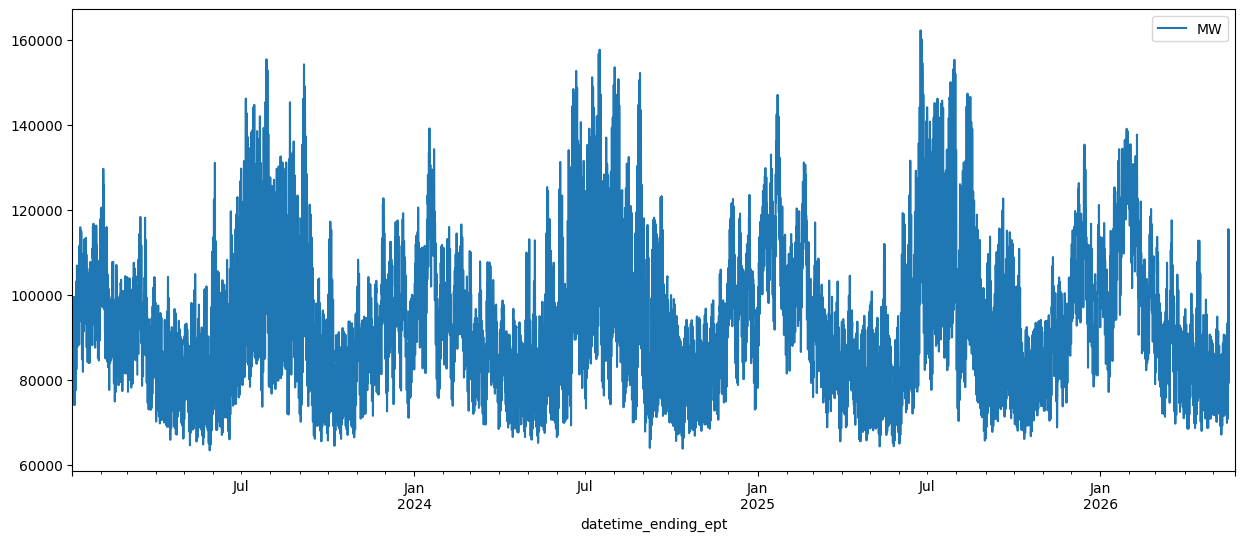

In [39]:
rto_load.plot(x="datetime_ending_ept", y=["MW"], figsize=(15, 6))

In [40]:
rto_load.columns

Index(['datetime_ending_ept', 'MW', 'temperature_2m', 'temperature_2m_std',
       'apparent_temperature', 'apparent_temperature_std', 'dew_point_2m',
       'dew_point_2m_std', 'relative_humidity_2m', 'relative_humidity_2m_std',
       'precipitation', 'precipitation_std', 'rain', 'rain_std', 'snowfall',
       'snowfall_std', 'snow_depth', 'snow_depth_std', 'cloud_cover',
       'cloud_cover_std', 'cloud_cover_low', 'cloud_cover_low_std',
       'cloud_cover_mid', 'cloud_cover_mid_std', 'cloud_cover_high',
       'cloud_cover_high_std', 'wind_speed_10m', 'wind_speed_10m_std',
       'wind_direction_10m', 'wind_direction_10m_std', 'wind_gusts_10m',
       'wind_gusts_10m_std', 'surface_pressure', 'surface_pressure_std',
       'pressure_msl', 'pressure_msl_std', 'et0_fao_evapotranspiration',
       'et0_fao_evapotranspiration_std', 'vapour_pressure_deficit',
       'vapour_pressure_deficit_std', 'shortwave_radiation',
       'shortwave_radiation_std', 'direct_radiation', 'direct_radia

### LightGBM

In [41]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []
feat_imp_results = []

start_date = (pd.Timestamp.today() - pd.Timedelta(days=offset)).normalize() # pd.Timestamp("2026-03-25")
end_date   = start_date + pd.Timedelta(days=2) - pd.Timedelta(hours=1) # pd.Timestamp("2026-03-26")

current_date = start_date

while current_date <= end_date:

    print(f"Running for {current_date.date()}")

    # cutoff = previous day at 10:00
    cutoff = (current_date - pd.Timedelta(days=1)).replace(hour=10)

    # train set: only information available by cutoff
    train_df = rto_load[
        rto_load["datetime_ending_ept"] <= cutoff
    ].copy()

    # test set: full target day
    test_start = current_date.replace(hour=1)
    test_end   = current_date.replace(hour=23) + pd.Timedelta(hours=1)

    test_df = rto_load[
        (rto_load["datetime_ending_ept"] >= test_start) &
        (rto_load["datetime_ending_ept"] <= test_end)
    ].copy()

    # skip if empty
    if train_df.empty or test_df.empty:
        print("Skipping because train/test is empty")
        current_date += pd.Timedelta(days=1)
        continue

    target = "MW"

    drop_cols = ["MW", "datetime_ending_ept", "zone", "date"]
    features = [col for col in train_df.columns if col not in drop_cols]

    # Time-based validation split from training data
    # use the most recent 14 days of hourly data as validation
    valid_hours = 24 * 7
    
    train_part = train_df.iloc[:-valid_hours].copy()
    valid_part = train_df.iloc[-valid_hours:].copy()

    X_train = train_part[features]
    y_train = train_part[target]

    X_valid = valid_part[features]
    y_valid = valid_part[target]

    X_test = test_df[features]

    # # weights
    # train_day = train_part["datetime_ending_ept"].dt.floor("D")
    # target_date = pd.Timestamp(current_date).floor("D")

    # # 1) Recency
    # days_from_end = (train_day.max() - train_day).dt.days
    # w_recency = np.exp(-days_from_end / 45)

    # # 2) Seasonal alignment (day-of-year closeness)
    # train_doy = train_part["datetime_ending_ept"].dt.dayofyear
    # target_doy = target_date.dayofyear

    # # handle year wrap-around
    # doy_diff = np.abs(train_doy - target_doy)
    # doy_diff = np.minimum(doy_diff, 365 - doy_diff)

    # w_season = np.exp(-doy_diff / 25)

    # # 3) Explicit YoY alignment to same period in prior years
    # yoy_dates = [target_date - pd.DateOffset(years=i) for i in range(1, 4)]

    # dist_yoy = np.min(
    #     np.column_stack([
    #         np.abs((train_day - d).dt.days.values) for d in yoy_dates
    #     ]),
    #     axis=1
    # )
    # w_yoy = np.exp(-dist_yoy / 10)

    # # 4) Temperature similarity
    # # Use test-day temp by hour if available from test_df.
    # # This is appropriate only if those temperatures are forecast inputs.
    # if "temperature_2m" in test_df.columns:
    #     temp_target_by_hour = (
    #         test_df.groupby("hour")["temperature_2m"]
    #         .mean()
    #         .to_dict()
    #     )
    #     target_temp_hour = train_part["hour"].map(temp_target_by_hour)
    # else:
    #     # fallback: same-month historical hourly median
    #     target_temp_hour = train_part["hour"].map(
    #         train_part.loc[train_part["month"] == target_date.month]
    #         .groupby("hour")["temperature_2m"]
    #         .median()
    #     )

    # # if some hours are missing, backfill with overall median by hour
    # fallback_hour_temp = train_part.groupby("hour")["temperature_2m"].median()
    # target_temp_hour = target_temp_hour.fillna(train_part["hour"].map(fallback_hour_temp))

    # temp_diff = np.abs(train_part["temperature_2m"] - target_temp_hour)
    # w_temp = np.exp(-temp_diff / 6)

    # # 5) Weekday similarity
    # target_dow = target_date.dayofweek
    # dow_diff = np.abs(train_part["day_of_week"] - target_dow)
    # dow_diff = np.minimum(dow_diff, 7 - dow_diff)
    # w_dow = np.exp(-dow_diff / 1.5)

    # # 6) Weekend structure
    # target_is_weekend = int(target_date.dayofweek >= 5)
    # w_weekend = np.where(train_part["is_weekend"] == target_is_weekend, 1.0, 0.45)

    # # 7) Holiday structure
    # # If holiday flag for forecast date is known from test_df, use it
    # if "is_holiday" in test_df.columns and not test_df.empty:
    #     target_is_holiday = int(test_df["is_holiday"].max())
    # else:
    #     target_is_holiday = 0

    # w_holiday = np.where(train_part["is_holiday"] == target_is_holiday, 1.0, 0.30)

    # # Final combined weights
    # weights = (
    #     w_recency
    #     * (0.7 + 0.3 * w_season)
    #     * (0.7 + 0.3 * w_yoy)
    #     * (0.6 + 0.4 * w_temp)
    #     * (0.8 + 0.2 * w_dow)
    #     * w_weekend
    #     * w_holiday
    # )

    # # stabilize
    # weights = np.clip(weights, 0.10, 8.0)
    # weights = weights / np.mean(weights)

    # # align to X_train rows
    # weights = pd.Series(weights, index=train_part.index).loc[X_train.index].values

    # Train model with recommended params + early stopping
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        # sample_weight=weights,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            __import__("lightgbm").early_stopping(100),
            __import__("lightgbm").log_evaluation(100)
        ]
    )

    # feature importance 
    feat_imp = pd.DataFrame({
        "date": current_date,
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    feat_imp["rank"] = range(1, len(feat_imp) + 1)
    feat_imp_results.append(feat_imp)


    test_df["MW_pred"] = model.predict(X_test)

    # PJM forecast 
    forecast_df = (
        rto_load_forecast[
            (rto_load_forecast["forecast_datetime_ending_ept"] >= test_start) &
            (rto_load_forecast["forecast_datetime_ending_ept"] <= test_end)
        ]
        .sort_values(["forecast_datetime_ending_ept"])
        .copy()
    )

    forecast_df = forecast_df.rename(columns={
        "forecast_datetime_ending_ept": "datetime_ending_ept"
    })

    forecast_df["datetime_ending_ept"] = pd.to_datetime(
        forecast_df["datetime_ending_ept"]
    )

    compare_df = pd.merge(
        test_df,
        forecast_df[["datetime_ending_ept", "forecast_load_mw"]],
        on="datetime_ending_ept",
        how="inner"
    )

    mae = mean_absolute_error(compare_df["forecast_load_mw"], compare_df["MW_pred"])
    rmse = np.sqrt(mean_squared_error(compare_df["forecast_load_mw"], compare_df["MW_pred"]))

    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

    compare_df["date"] = current_date
    compare_df["MAE"] = mae
    compare_df["RMSE"] = rmse

    results.append(compare_df)

    current_date += pd.Timedelta(days=1)

# combine all days
final_results = pd.concat(results, ignore_index=True)

Running for 2026-05-18
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20306
[LightGBM] [Info] Number of data points in the train set: 29387, number of used features: 93
[LightGBM] [Info] Start training from score 94410.054639
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 2141.93	valid_0's l2: 4.58788e+06
[200]	valid_0's rmse: 2095.89	valid_0's l2: 4.39275e+06
Early stopping, best iteration is:
[147]	valid_0's rmse: 2039.57	valid_0's l2: 4.15985e+06
MAE: 6693.72, RMSE: 9048.72
Running for 2026-05-19
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20306
[LightGBM] [Info] Number of data points in the train set: 29411, number of used features: 93
[LightGBM] [Info] Start 

In [42]:
mean_mae = final_results["MAE"].mean()
mean_rmse = final_results["RMSE"].mean()

print(mean_mae, mean_rmse)

5662.196285214341 7453.4793754765415


In [43]:
import plotly.graph_objects as go

plot_df = final_results.sort_values("datetime_ending_ept")

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_df["datetime_ending_ept"],
    y=plot_df["MW_pred"],
    mode="lines",
    name="Model Prediction (MW_pred)"
))

fig.add_trace(go.Scatter(
    x=plot_df["datetime_ending_ept"],
    y=plot_df["forecast_load_mw"],
    mode="lines",
    name="PJM Forecast (forecast_load_mw)"
))

fig.update_layout(
    title=(
        f"Model vs PJM Forecast Load "
        f"({start_date.strftime('%Y-%m-%d')} - {end_date.strftime('%Y-%m-%d')})<br>"
        f"Model → MAE: {mean_mae:.2f}, RMSE: {mean_rmse:.2f} "
    ),
    xaxis_title="Time",
    yaxis_title="MW",
    template="plotly_white"
)

fig.show()

### save

In [44]:
today = datetime.today() - timedelta(days=offset)

start_str = today.strftime("%m%d")                 # 0325
end_str = (today + timedelta(days=1)).strftime("%m%d")  # 0326
run_str = today.strftime("%y%m%d")                 # 260325

final_results[
    ['datetime_ending_ept', 'date', 'hour', 'MW_pred', 'forecast_load_mw']
].to_csv(
    f'data/prediction/RTO_prediction_{start_str}_to_{end_str}_at_{run_str}.csv',
    index=False
)